# Data Compression & Incremental Analysis of Principal Components

_**Consider an appropriate dataset to experiment with data compression and incremental analysis of principal components using Principal Component Analysis (PCA).**_

In [1]:
# Import required packages

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, IncrementalPCA
import matplotlib.pyplot as plt
import pickle

## Retrieval & Preparation of Data

In [2]:
# Loads the MNIST dataset
with open("./../../data/mnist_784.pickle", "rb") as file:
    X_mnist, y_mnist = pickle.load(file)

# Checks the shape of the dataset
print(X_mnist.shape)

(70000, 784)


In [3]:
# Splits dataset into train and test set containing 60000 and 10000 instances, respectively.

X_train, X_test, y_train, y_test = train_test_split(
    X_mnist, y_mnist, test_size=10000, random_state=42, stratify=y_mnist)

## Data Compression using PCA

_**Finds the compression ratio after dimensionality reduction and then performs decompression of the compressed data to its original dimensions to do visual comparision between the original and compressed data.**_

In [4]:
# PCA is initialized with the minimum requirement of explained variance
pca = PCA(n_components=0.95)

# Applies the dimensionality reduction on the train set and it returns minimum number of 
# principal components that can explain a given variance
X_train_reduced = pca.fit_transform(X_train)

# Prints the number of principal components
print("Number of principal components: ", pca.n_components_)

Number of principal components:  154


**Calculates the compression**

In [5]:
# Calculates required space
# It is defined as ratio between the number of principal components that describes 
# the given variance and number of dimensions of the original dataset

required_space = pca.n_components_ / X_mnist.shape[1] * 100
print(f"Required space: {required_space:0.2f}%", )
print(f"Compression: {(100 - required_space): .2f}%")     # Calculates compression

Required space: 19.64%
Compression:  80.36%


**Visual Comparision between the Original and Decompressed Data**

In [6]:
# Decompresses the reduced dataset back to its original dimensions i.e. 784
# by applying the inverse transformation of the PCA projection.

X_train_recovered = pca.inverse_transform(X_train_reduced)

# Checks the shape of the recovered dataset
print(X_train_recovered.shape)

(60000, 784)


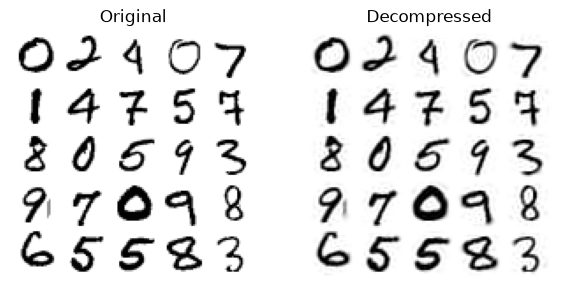

In [7]:
# Plots few digits from the original training set on the left, and
# the corresponding digits after compression and decompression

plt.figure(figsize=(7, 4))
for idx, X in enumerate((X_train, X_train_recovered)):
    plt.subplot(1, 2, idx + 1)
    plt.title(["Original", "Decompressed"][idx])
    for row in range(5):
        for col in range(5):
            plt.imshow(
                X[row * 5 + col].reshape(28, 28), 
                cmap="binary",       # colormap to refer to map input data 
                vmin=0, vmax=255,    # data range the colormap covers [to be used when input data is not normalized]
                extent=(row, row + 1, col, col + 1), # bounding box the image is stretched to fill in
            ) 
            plt.axis([0, 5, 0, 5])   # axis limits as [x_min, x_max, y_min, y_max]
            plt.axis("off")          # hides all axis decorations including labels

## Incremental Analysis of Principal Components using PCA

Incremental PCA will be useful in scenario especially when training set is large and cann't be fit into memory. The following experiment simulates the same scenario considering training set is stored into a file and the task is to apply PCA incrementally over mini-batches.

In [8]:
# Creates a training set file. Successful execution of these statements 
# would save MNIST training set into a file of size around 190 MB on disk.

train_set_memmap_filename = "./my_mnist.mmap"

# Creates a memory-map to an array to be stored in file on disk.
X_train_memmap = np.memmap(train_set_memmap_filename, dtype="float32", mode="write", shape=X_train.shape)

# Loads the data into the memory map
X_train_memmap[:] = X_train

# Saves the data into the file on disk
X_train_memmap.flush()

Now, considering this file is large enough to load into memory, the data gets loaded over small batches and feed into incremental PCA algorithm.

In [9]:
# Initializes the memory-mapped file. It helps accessing small segments of large files on disk, 
# without reading the entire file into memory.
X_train_memmap = np.memmap(train_set_memmap_filename, dtype="float32", mode="readonly", shape=X_train.shape)

In [10]:
# Defines number of batches
n_batches = 100

# Defines size (number of instances) in each batch
n_batch_size = X_train_memmap.shape[0] // n_batches

In [12]:
# Instantiate incremental PCA algorithm

incremental_pca = IncrementalPCA(
    n_components=pca.n_components_,    # pca.n_components_ returns 154 as these number of 
                                       # components explains the given variance
    batch_size=n_batch_size)

In [13]:
# Extracts the principal components incrementally by fetching batches over 
# the memory mapped to data file on disk 
# NOTE: This step may take several seconds to complete

incremental_pca.fit(X_train_memmap)  

,"n_components n_components: int, default=NoneNumber of components to keep. If ``n_components`` is ``None``,then ``n_components`` is set to ``min(n_samples, n_features)``.",np.int64(154)
,"batch_size batch_size: int, default=NoneThe number of samples to use for each batch. Only used when calling``fit``. If ``batch_size`` is ``None``, then ``batch_size``is inferred from the data and set to ``5 * n_features``, to provide abalance between approximation accuracy and memory consumption.",600
,"whiten whiten: bool, default=FalseWhen True (False by default) the ``components_`` vectors are dividedby ``n_samples`` times ``components_`` to ensure uncorrelated outputswith unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimesimprove the predictive accuracy of the downstream estimators bymaking data respect some hard-wired assumptions.",False
,"copy copy: bool, default=TrueIf False, X will be overwritten. ``copy=False`` can be used tosave memory but is unsafe for general use.",True
Name,Type,Value
batch_size_ batch_size_: intInferred batch size from ``batch_size``.,int,600
"components_ components_: ndarray of shape (n_components, n_features)Principal axes in feature space, representing the directions ofmaximum variance in the data. Equivalently, the right singularvectors of the centered input data, parallel to its eigenvectors.The components are sorted by decreasing ``explained_variance_``.","ndarray[float64](154, 784)","[[ 0., 0., 0.,..., 0., 0., 0.], [-0.,-0., 0.,...,-0.,-0.,-0.], [-0., 0., 0.,..., 0., 0., 0.], ..., [ 0., 0.,-0.,...,-0.,-0.,-0.], [ 0., 0., 0.,..., 0., 0., 0.], [-0., 0., 0.,..., 0., 0., 0.]]"
"explained_variance_ explained_variance_: ndarray of shape (n_components,)Variance explained by each of the selected components.","ndarray[float64](154,)","[334219.63,245179.42,210721.21,..., 1450.89, 1435.26, 1403.25]"
"explained_variance_ratio_ explained_variance_ratio_: ndarray of shape (n_components,)Percentage of variance explained by each of the selected components.If all components are stored, the sum of explained variances is equalto 1.0.","ndarray[float64](154,)","[0.1 ,0.07,0.06,...,0. ,0. ,0. ]"
"mean_ mean_: ndarray of shape (n_features,)Per-feature empirical mean, aggregate over calls to ``partial_fit``.","ndarray[float64](784,)","[0.,0.,0.,...,0.,0.,0.]"
n_components_ n_components_: intThe estimated number of components. Relevant when``n_components=None``.,int64,np.int64(154)


In [15]:
# Sums up variance explained by each of the 154 principal components to ensure that it is 
# equal to 95% which is the expected explained variance from the reduced data

print(f"Explained variance ratio by train set made of principal components: \
      {np.sum(incremental_pca.explained_variance_ratio_): .2f}%")

Explained variance ratio by train set made of principal components:        0.95%


**Observations:**

1. Visual comparision between the original and compressed data, it was noticed that there is a slight loss in image quality due to fact that the PCA projection lost a bit of information for the given 5% variance reduction, but the digits are still mostly intact.
2. Increamental PCA algorithm successfully extracted principal components by incrementally processing data over mini batches loaded through memory mapped data file stored on disk and it demonstrated that if the data file is large enough to be loaded in memory at once, incremental PCA can be an effective way to extract principal components.